In [20]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
plt.style.use('ggplot')
sns.set_palette('colorblind')

# Load your dataset
df = pd.read_csv('updated_file_with_predictions.csv')  # Adjust filename as needed

# Explore the dataset
print(f"Dataset shape: {df.shape}")
print(df.head())
print(df['Valence'].value_counts())

# Check for missing values
print(df.isnull().sum())

# Display some examples from each category
for category in ['NEGATIVE', 'NEUTRAL', 'POSITIVE', 'MIXED']:
    print(f"\n--- {category} Examples ---")
    print(df[df['Valence'] == category]['Review'].sample(3).values)

Dataset shape: (1001, 8)
                                              Review  Star Rating  Length  \
0                     sir okay armygreen shorts nice            5       5   
1  di pareha yong mga size nila may sobrang liit ...            5      10   
2  super worth it ang ganda sombra grabi order na...            5      22   
3                                   ganda po salamat            5       3   
4                maayos pagkadeliver maganda den sya            5       5   

    Valence Internal Consistency  Review Quality  Template Flag  Credibility  
0  POSITIVE           CONSISTENT             NaN            NaN          NaN  
1  NEGATIVE         INCONSISTENT             NaN            NaN          NaN  
2  POSITIVE           CONSISTENT             NaN            NaN          NaN  
3  POSITIVE           CONSISTENT             NaN            NaN          NaN  
4  POSITIVE           CONSISTENT             NaN            NaN          NaN  
Valence
NEGATIVE    436
POSITIVE    36

In [3]:
# Explore the dataset structure
print(f"Dataset shape: {df.shape}")
print(df.head())
print(df['Valence'].value_counts())

Dataset shape: (1001, 8)
                                              Review  Star Rating  Length  \
0                     sir okay armygreen shorts nice            5       5   
1  di pareha yong mga size nila may sobrang liit ...            5      10   
2  super worth it ang ganda sombra grabi order na...            5      22   
3                                   ganda po salamat            5       3   
4                maayos pagkadeliver maganda den sya            5       5   

    Valence Internal Consistency  Review Quality  Template Flag  Credibility  
0  POSITIVE           CONSISTENT             NaN            NaN          NaN  
1  NEGATIVE         INCONSISTENT             NaN            NaN          NaN  
2  POSITIVE           CONSISTENT             NaN            NaN          NaN  
3  POSITIVE           CONSISTENT             NaN            NaN          NaN  
4  POSITIVE           CONSISTENT             NaN            NaN          NaN  
Valence
NEGATIVE    436
POSITIVE    36

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Feature extraction directly on raw text (skipping preprocessing)
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['Review'])
print(f"TF-IDF features shape: {X_tfidf.shape}")

TF-IDF features shape: (1001, 10000)


In [6]:
from sklearn.preprocessing import LabelEncoder

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['Valence'])

In [7]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (800, 10000), Test set: (201, 10000)


In [8]:
from sklearn.linear_model import LogisticRegression

# Train model
model = LogisticRegression(max_iter=1000, C=1.0)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
# Identify key features for each class
def get_important_features(vectorizer, model, class_idx):
    feature_names = vectorizer.get_feature_names_out()

    if hasattr(model, 'coef_'):
        coefficients = model.coef_[class_idx]
        top_features = np.argsort(coefficients)[-20:]  # Top 20 features
        return [(feature_names[i], coefficients[i]) for i in top_features]

    return []

# For each class
for i, class_name in enumerate(label_encoder.classes_):
    print(f"Top features for {class_name}:")
    top_features = get_important_features(tfidf, model, i)
    for feature, coef in top_features:
        print(f"  - {feature}: {coef:.4f}")

Top features for MIXED:
  - sa: 0.5495
  - nga: 0.5791
  - medyo: 0.5930
  - tela: 0.6132
  - kulay: 0.6162
  - pero ok: 0.6496
  - di: 0.6649
  - the: 0.6950
  - for: 0.7010
  - lng: 0.7363
  - however: 0.8285
  - okay: 0.8305
  - ok: 0.8310
  - na: 0.9564
  - kaso: 0.9704
  - yung: 0.9798
  - but: 1.0776
  - lang: 1.0834
  - naman: 1.0984
  - pero: 1.1881
Top features for NEGATIVE:
  - gray: 0.6112
  - tapos: 0.6128
  - wrong color: 0.6234
  - inorder ko: 0.6301
  - xl: 0.6796
  - nyo: 0.6809
  - size: 0.6983
  - order ko: 0.7287
  - ko: 0.7313
  - disappointed: 0.7609
  - manipis: 0.7949
  - white: 0.8109
  - was: 0.8115
  - color: 0.8149
  - kulang: 0.8169
  - wrong: 0.8692
  - nipis: 0.8840
  - dumating: 0.8891
  - poor: 1.0688
  - not: 1.4916
Top features for NEUTRAL:
  - see is: 0.3454
  - you: 0.3672
  - green received: 0.3759
  - greens: 0.3759
  - back: 0.4262
  - get: 0.4858
  - black: 0.5864
  - what: 0.6691
  - order is: 0.6885
  - is black: 0.7610
  - may order: 0.7610
  

In [14]:
# Option 1: Use class weights
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

weighted_model = LogisticRegression(max_iter=1000, class_weight=class_weight_dict)
weighted_model.fit(X_train, y_train)

LogisticRegression(class_weight={0: np.float64(1.6),
                                 1: np.float64(0.5747126436781609),
                                 2: np.float64(5.2631578947368425),
                                 3: np.float64(0.6920415224913494)},
                   max_iter=1000)

In [11]:
# Option 2: Oversample minority classes
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

model_resampled = LogisticRegression(max_iter=1000)
model_resampled.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=1000)

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Evaluate
y_pred = weighted_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.8010

Classification Report:
              precision    recall  f1-score   support

       MIXED       0.71      0.69      0.70        32
    NEGATIVE       0.81      0.85      0.83        88
     NEUTRAL       0.50      0.22      0.31         9
    POSITIVE       0.85      0.86      0.86        72

    accuracy                           0.80       201
   macro avg       0.72      0.66      0.67       201
weighted avg       0.79      0.80      0.79       201



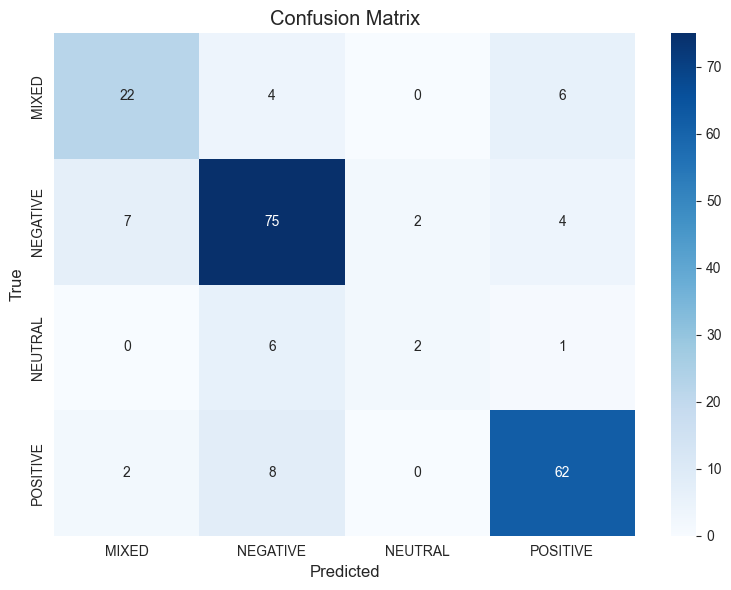

In [16]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=label_encoder.classes_,
           yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Create a prediction function
def predict_sentiment(text):
    # Vectorize
    X = tfidf.transform([text])

    # Predict
    prediction = weighted_model.predict(X)[0]

    # Return class label
    return label_encoder.classes_[prediction]

# Test with examples
test_texts = [
    "kudos to this shop lowest srp nung nagplaced ako ng order and yet sulit ang mga freebies medyo kabado pa nung una kahit lazmall sya kasi baka bato laman ng package and ang mura pero pagdating i was amazed"
]

for text in test_texts:
    sentiment = predict_sentiment(text)
    print(f"Text: {text}")
    print(f"Predicted sentiment: {sentiment}\n")

import pandas as pd

# Load your CSV file
df = pd.read_csv('updated_test_with_predictions.csv')  # Replace with your actual filename

# Prediction function
def predict_sentiment(text):
    X = tfidf.transform([text])
    prediction = weighted_model.predict(X)[0]
    return label_encoder.classes_[prediction]

# Overwrite the 'Valence' column with predictions
df['Valence'] = df['Review'].apply(predict_sentiment)

# Show a few rows to verify
print(df[['Review', 'Valence']].head())

# Optional: Save to a new file
df.to_csv('updated_test_with_predictions.csv', index=False)


In [61]:
import pickle

# 1. Save the trained model
with open('sentiment_classifier_v2.pkl', 'wb') as file:
    pickle.dump(model, file)

# 2. Save the TF-IDF vectorizer (crucial for transforming new text the same way)
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf, file)

# 3. Save the label encoder (to convert numeric predictions back to sentiment labels)
with open('label_encoder.pkl', 'wb') as file:
    pickle.dump(label_encoder, file)

print("Model and necessary components saved successfully!")

Model and necessary components saved successfully!
